# GVH Diagonal Cubic — RACC-C.4-real.2.6
## GW150914 H1/L1 — Time-Frequency Transfer Stationarity Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.6`  
**Noyau GVH Diagonal modifié : NON**

### Question falsifiable

Tester si le transfert relatif H1→L1 peut être approximé par une fonction stationnaire :

\[
T_{H1\rightarrow L1}(f,t)
\stackrel{?}{\simeq}
T_{H1\rightarrow L1}(f).
\]

Si le transfert varie significativement dans le temps ou selon la zone fréquentielle du chirp, cela peut expliquer pourquoi `real.2.4` réussit **in-sample** alors que `real.2.5` échoue **out-of-sample**.

### Principe

Le chirp est découpé en tuiles temps-fréquence. Pour chaque tuile, on estime :

\[
T(f,t_k)=\frac{\langle L(f,t_k)H^*(f,t_k)\rangle}
{\langle |H(f,t_k)|^2\rangle+\epsilon}.
\]

On teste ensuite :

- stabilité de l'amplitude \(|T|\) ;
- stabilité de la phase \(\arg T\) ;
- stabilité de la pente de phase ;
- cohérence entre tuiles ;
- distance entre transferts locaux.

### Stop-rule

Ce notebook ne certifie pas le timing.

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]

La chaîne HH et `DISPERSION_READY` restent inchangées.


In [ ]:

import os,sys,subprocess,importlib,json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import median_abs_deviation
from gwpy.timeseries import TimeSeries

print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement H1/L1

In [ ]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists():
            continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("H1/L1 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")

h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print(H1.name)
print(L1.name)
print("N =",len(h1),"fs =",fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Prétraitement commun

In [ ]:

NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))

def center(x):
    return np.asarray(x,float)-np.mean(x)

def whiten(x):
    x=center(x)
    n=len(x)
    f=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    fp,P=signal.welch(x[NOISE],fs=fs,nperseg=4096)
    Pi=np.interp(f,fp,P,left=P[0],right=P[-1])
    floor=np.finfo(float).eps*np.max(Pi)
    y=np.fft.irfft(X/np.sqrt(Pi+floor),n=n)
    return y/np.std(y[NOISE])

def band_notch(x,lo=35,hi=350):
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,center(x))
    for f0 in [60,120,180,240,300]:
        if lo<f0<hi:
            b,a=signal.iirnotch(f0,Q=30,fs=fs)
            y=signal.filtfilt(b,a,y)
    return y

H=band_notch(whiten(h1))
L=band_notch(whiten(l1))

EVENT=(-.16,.08)
em=(t_rel>=EVENT[0])&(t_rel<=EVENT[1])

te=t_rel[em]
He=H[em]
Le=L[em]

print("event samples:",len(te))
print("duration [s]:",te[-1]-te[0])


event samples: 983
duration [s]: 0.23974609375


## 3 — STFT commune et transfert local

In [ ]:

NPER=256
NOVER=224

f,t,Zh=signal.stft(He,fs=fs,nperseg=NPER,noverlap=NOVER,
                   window="hann",boundary=None)
_,_,Zl=signal.stft(Le,fs=fs,nperseg=NPER,noverlap=NOVER,
                   window="hann",boundary=None)

# Time relative to event-window start
t_global=t+EVENT[0]

eps=np.finfo(float).eps
T_local=(Zl*np.conj(Zh))/(np.abs(Zh)**2 + eps)

power=np.abs(Zh)*np.abs(Zl)
coh_proxy=np.abs(Zl*np.conj(Zh))/(np.abs(Zh)*np.abs(Zl)+eps)

band=(f>=40)&(f<=300)
print("STFT shape:",Zh.shape)


STFT shape: (129, 24)


## 4 — Sélection des tuiles informatives

On ne conserve que les tuiles où la puissance conjointe est suffisamment élevée.

Cela évite de mesurer la stationnarité à partir de zones dominées par le bruit.


In [ ]:

P=power[band,:]
threshold=np.quantile(P,0.70)

tile_rows=[]

for j,tj in enumerate(t_global):
    m=band & (power[:,j]>=threshold)
    if m.sum()<6:
        continue

    Tl=T_local[m,j]
    ff=f[m]
    ww=power[m,j]

    amp=np.abs(Tl)
    ph=np.unwrap(np.angle(Tl))

    # weighted linear phase slope
    A=np.c_[ff,np.ones_like(ff)]
    W=np.sqrt(ww/np.max(ww))
    beta,*_=np.linalg.lstsq(A*W[:,None],ph*W,rcond=None)
    slope,inter=beta

    pred=A@beta
    pbar=np.average(ph,weights=ww)
    ssr=np.sum(ww*(ph-pred)**2)
    sst=np.sum(ww*(ph-pbar)**2)
    r2=1-ssr/sst if sst>0 else np.nan

    tile_rows.append({
        "t_center_s":float(tj),
        "n_freq":int(m.sum()),
        "amp_median":float(np.median(amp)),
        "amp_mad":float(median_abs_deviation(amp)),
        "phase_median_rad":float(np.median(ph)),
        "phase_mad_rad":float(median_abs_deviation(ph)),
        "phase_slope_tau_ms":float(slope/(2*np.pi)*1e3),
        "phase_r2":float(r2),
        "power_sum":float(np.sum(ww))
    })

tile_df=pd.DataFrame(tile_rows)
display(tile_df)
print("informative tiles =",len(tile_df))


,t_center_s,n_freq,amp_median,amp_mad,phase_median_rad,phase_mad_rad,phase_slope_tau_ms,phase_r2,power_sum
0,-0.128750,6,2.546970,0.998067,0.340424,0.846259,-1.320702,0.092622,0.010599
1,-0.120938,6,2.367111,1.191687,-0.994674,0.561805,-1.307857,0.062731,0.007437
2,-0.058438,7,3.336568,0.825769,-1.731531,0.884369,0.110267,0.001196,0.011973
3,-0.050625,7,3.104054,0.795755,-1.359160,0.840291,-0.776516,0.042328,0.012412
4,-0.042813,6,2.179361,0.621217,4.107282,1.436744,6.656564,0.857678,0.010272
5,-0.019375,6,1.922076,0.346865,2.218209,1.131806,4.845122,0.887265,0.009068
6,0.011875,6,2.442535,1.540206,-2.277199,0.529129,-1.885510,0.824670,0.011601
7,0.019687,9,4.140080,0.591488,-2.692056,0.893818,-2.385326,0.928705,0.012112
8,0.027500,7,3.310209,2.306418,-3.368764,0.275168,-2.837856,0.916763,0.009869


informative tiles = 9


## 5 — Visualisation de l'évolution temporelle

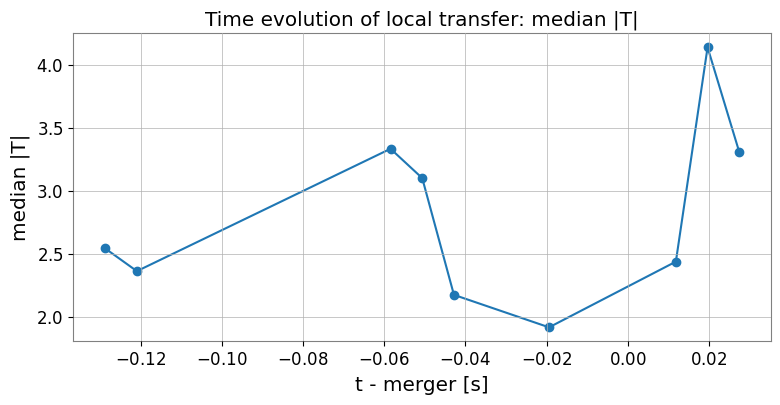

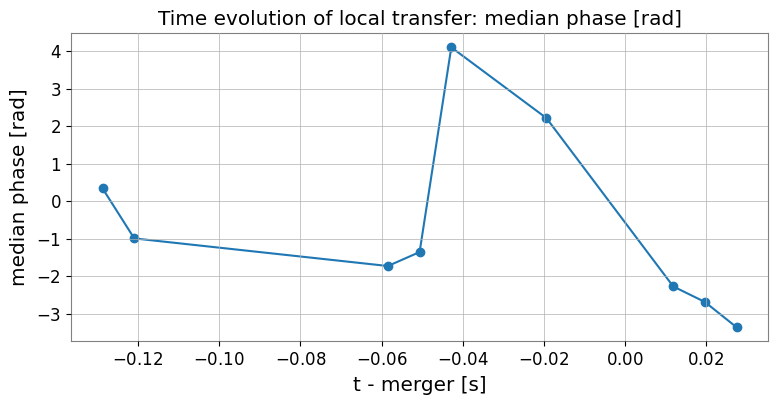

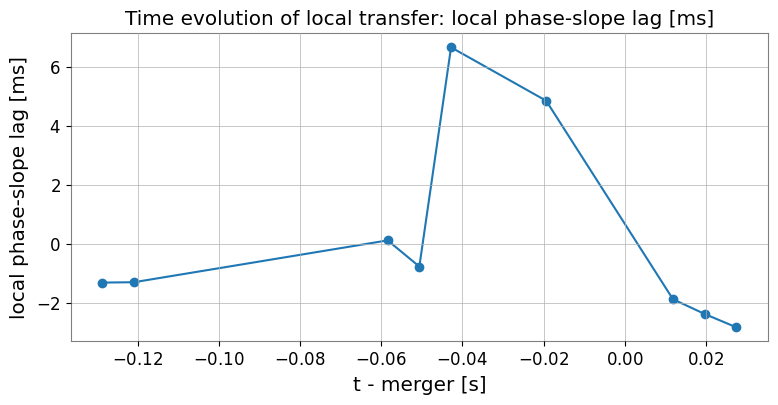

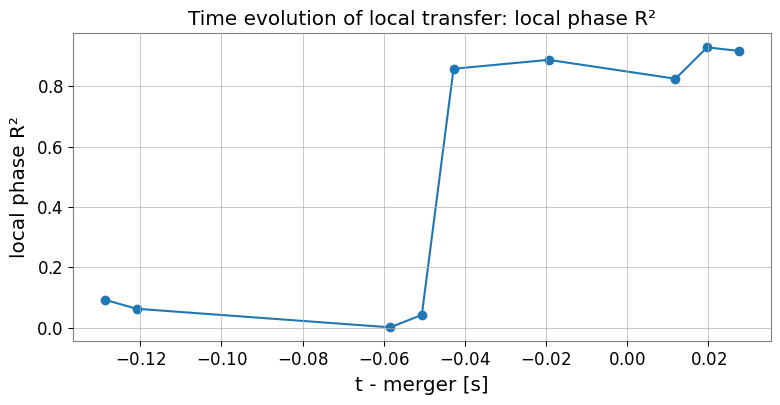

In [ ]:

fig_items=[
    ("amp_median","median |T|"),
    ("phase_median_rad","median phase [rad]"),
    ("phase_slope_tau_ms","local phase-slope lag [ms]"),
    ("phase_r2","local phase R²")
]

for col,label in fig_items:
    plt.figure(figsize=(9,4))
    plt.plot(tile_df.t_center_s,tile_df[col],marker="o")
    plt.xlabel("t - merger [s]")
    plt.ylabel(label)
    plt.title("Time evolution of local transfer: "+label)
    plt.grid(True)
    plt.show()


## 6 — Variabilité temporelle normalisée

In [ ]:

def robust_cv(x):
    x=np.asarray(x,float)
    med=np.nanmedian(x)
    mad=np.nanmedian(np.abs(x-med))
    return float(mad/(abs(med)+1e-12))

AMP_TEMPORAL_CV=robust_cv(tile_df.amp_median)
PHASE_TEMPORAL_MAD=float(np.nanmedian(np.abs(tile_df.phase_median_rad-np.nanmedian(tile_df.phase_median_rad))))
TAU_TEMPORAL_MAD_MS=float(np.nanmedian(np.abs(tile_df.phase_slope_tau_ms-np.nanmedian(tile_df.phase_slope_tau_ms))))

print("AMP_TEMPORAL_CV =",AMP_TEMPORAL_CV)
print("PHASE_TEMPORAL_MAD [rad] =",PHASE_TEMPORAL_MAD)
print("TAU_TEMPORAL_MAD [ms] =",TAU_TEMPORAL_MAD_MS)


AMP_TEMPORAL_CV = 0.21872427758408816
PHASE_TEMPORAL_MAD [rad] = 1.3328957652713052
TAU_TEMPORAL_MAD [ms] = 1.0774687872407767


## 7 — Transferts moyens par blocs temporels

In [ ]:

TIME_BLOCKS=[
    ("early",-.16,-.08),
    ("mid",-.08,0.00),
    ("late",0.00,.08)
]

block_transfers={}
block_rows=[]

for name,t0,t1 in TIME_BLOCKS:
    tm=(t_global>=t0)&(t_global<t1)
    if tm.sum()<2:
        continue

    Zhb=Zh[:,tm]
    Zlb=Zl[:,tm]

    num=np.sum(Zlb*np.conj(Zhb),axis=1)
    den=np.sum(np.abs(Zhb)**2,axis=1)+eps
    Tb=num/den
    block_transfers[name]=Tb

    mb=band & np.isfinite(Tb)
    block_rows.append({
        "block":name,
        "amp_median":float(np.median(np.abs(Tb[mb]))),
        "phase_median_rad":float(np.median(np.unwrap(np.angle(Tb[mb]))))
    })

block_df=pd.DataFrame(block_rows)
display(block_df)


,block,amp_median,phase_median_rad
0,early,1.664662,-4.616309
1,mid,1.442079,-8.477824
2,late,1.660944,-2.536806


## 8 — Distance entre transferts temporels

In [ ]:

pairs=[]
names=list(block_transfers.keys())

def transfer_distance(Ta,Tb,mask):
    a=Ta[mask]
    b=Tb[mask]

    # normalized complex L2 distance
    denom=np.linalg.norm(a)+np.linalg.norm(b)+1e-12
    d_complex=np.linalg.norm(a-b)/denom

    amp_a=np.abs(a); amp_b=np.abs(b)
    d_amp=np.median(np.abs(amp_a-amp_b))/(np.median((amp_a+amp_b)/2)+1e-12)

    ph_a=np.unwrap(np.angle(a))
    ph_b=np.unwrap(np.angle(b))
    d_phase=float(np.median(np.abs(ph_a-ph_b)))

    return float(d_complex),float(d_amp),float(d_phase)

for i in range(len(names)):
    for j in range(i+1,len(names)):
        a=names[i]; b=names[j]
        d1,d2,d3=transfer_distance(block_transfers[a],block_transfers[b],band)
        pairs.append({
            "pair":f"{a}-{b}",
            "complex_distance":d1,
            "relative_amp_distance":d2,
            "median_phase_distance_rad":d3
        })

pair_df=pd.DataFrame(pairs)
display(pair_df)


,pair,complex_distance,relative_amp_distance,median_phase_distance_rad
0,early-mid,0.698196,0.465503,4.792243
1,early-late,0.847010,0.433312,2.496007
2,mid-late,0.631741,0.544663,5.731318


## 9 — Stationnarité fréquentielle

In [ ]:

FREQ_BLOCKS=[
    ("low",40,100),
    ("mid",100,180),
    ("high",180,300)
]

freq_rows=[]

for name,lo,hi in FREQ_BLOCKS:
    fm=(f>=lo)&(f<hi)
    vals=[]

    for j,tj in enumerate(t_global):
        m=fm & (power[:,j]>=threshold)
        if m.sum()<4:
            continue

        Tl=T_local[m,j]
        vals.append({
            "t":tj,
            "amp":float(np.median(np.abs(Tl))),
            "phase":float(np.median(np.unwrap(np.angle(Tl))))
        })

    if vals:
        d=pd.DataFrame(vals)
        freq_rows.append({
            "band":name,
            "amp_temporal_cv":robust_cv(d.amp),
            "phase_temporal_mad_rad":float(np.nanmedian(np.abs(d.phase-np.nanmedian(d.phase)))),
            "n_tiles":len(d)
        })

freq_df=pd.DataFrame(freq_rows)
display(freq_df)


,band,amp_temporal_cv,phase_temporal_mad_rad,n_tiles
0,mid,0.338942,0.015282,3
1,high,0.066102,3.388447,9


## 10 — Critères de stationnarité

Le transfert est considéré approximativement stationnaire si :

- variation robuste d'amplitude faible ;
- variation de phase faible ;
- dispersion temporelle de la pente faible ;
- distances entre blocs temporels faibles.

Ces seuils sont des critères de benchmark, pas des constantes GVH.


In [ ]:

AMP_STABLE=bool(AMP_TEMPORAL_CV<0.25)
PHASE_STABLE=bool(PHASE_TEMPORAL_MAD<0.50)
TAU_STABLE=bool(TAU_TEMPORAL_MAD_MS<1.0)

if len(pair_df):
    BLOCK_COMPLEX_STABLE=bool(np.nanmedian(pair_df.complex_distance)<0.20)
    BLOCK_PHASE_STABLE=bool(np.nanmedian(pair_df.median_phase_distance_rad)<0.50)
else:
    BLOCK_COMPLEX_STABLE=False
    BLOCK_PHASE_STABLE=False

STATIONARITY_GATES={
    "AMP_STABLE":AMP_STABLE,
    "PHASE_STABLE":PHASE_STABLE,
    "TAU_STABLE":TAU_STABLE,
    "BLOCK_COMPLEX_STABLE":BLOCK_COMPLEX_STABLE,
    "BLOCK_PHASE_STABLE":BLOCK_PHASE_STABLE
}

N_STABLE=int(sum(STATIONARITY_GATES.values()))
TRANSFER_STATIONARY=bool(N_STABLE>=4)

print(json.dumps(STATIONARITY_GATES,indent=2))
print("N_STABLE =",N_STABLE)
print("TRANSFER_STATIONARY =",TRANSFER_STATIONARY)


{
  "AMP_STABLE": true,
  "PHASE_STABLE": false,
  "TAU_STABLE": false,
  "BLOCK_COMPLEX_STABLE": false,
  "BLOCK_PHASE_STABLE": false
}
N_STABLE = 1
TRANSFER_STATIONARY = False


## 11 — Verdict

In [ ]:

if len(tile_df)<5 or len(pair_df)<2:
    FINAL_STATUS="UNRESOLVED"
elif TRANSFER_STATIONARY:
    FINAL_STATUS="TRANSFER-APPROX-STATIONARY"
else:
    FINAL_STATUS="TRANSFER-TIME-FREQUENCY-NONSTATIONARY"

artifact={
    "step":"RACC-C.4-real.2.6",
    "event":"GW150914",
    "question":"T_H1_to_L1(f,t) ~= T_H1_to_L1(f)?",
    "tile_count":int(len(tile_df)),
    "amp_temporal_cv":AMP_TEMPORAL_CV,
    "phase_temporal_mad_rad":PHASE_TEMPORAL_MAD,
    "tau_temporal_mad_ms":TAU_TEMPORAL_MAD_MS,
    "stationarity_gates":STATIONARITY_GATES,
    "N_STABLE":N_STABLE,
    "TRANSFER_STATIONARY":TRANSFER_STATIONARY,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}

print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.6",
  "event": "GW150914",
  "question": "T_H1_to_L1(f,t) ~= T_H1_to_L1(f)?",
  "tile_count": 9,
  "amp_temporal_cv": 0.21872427758408816,
  "phase_temporal_mad_rad": 1.3328957652713052,
  "tau_temporal_mad_ms": 1.0774687872407767,
  "stationarity_gates": {
    "AMP_STABLE": true,
    "PHASE_STABLE": false,
    "TAU_STABLE": false,
    "BLOCK_COMPLEX_STABLE": false,
    "BLOCK_PHASE_STABLE": false
  },
  "N_STABLE": 1,
  "TRANSFER_STATIONARY": false,
  "final_status": "TRANSFER-TIME-FREQUENCY-NONSTATIONARY",
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "REAL3_AUTHORIZED": false,
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "core_GVH_modified": false
}


## 12 — Stop-rule finale

Si :

\[
\boxed{\texttt{TRANSFER-TIME-FREQUENCY-NONSTATIONARY}}
\]

alors l'échec de `real.2.5` devient compatible avec un transfert H1↔L1 variant le long du chirp.

Cela ne suffit toujours pas à certifier le timing.

La suite devra alors tester un **modèle de transfert local ou paramétrique**, avec validation hors-échantillon adaptée à la structure temps-fréquence.

Si le transfert est approximativement stationnaire, il faudra rechercher une autre cause à l'échec cross-validé.

Dans tous les cas :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]
